## Find reflectivity of given multilayer structure by transfer matrix method

In [1]:
import matplotlib.pyplot as plt
from phc_codes.phc_utils import refractive_index, generate_lambda
from phc_codes.TMM import PhCTransferMatrix
import numpy as np

## Refractive index data

In [2]:
n_scotch_tape = 1.5
n_quartz = (
    lambda x: (
        1
        + 0.6961663 / (1 - (0.0684043 / x) ** 2)
        + 0.4079426 / (1 - (0.1162414 / x) ** 2)
        + 0.8974794 / (1 - (9.896161 / x) ** 2)
    )
    ** 0.5
)  # Quartz #
n_si = refractive_index("Si")
npva = 1.457 + 0.0002j

## Define the structure

In [3]:
ni = 1.0
nf = refractive_index("Quartz_expt")
nh = refractive_index("TiO2_expt")  # 2.41 + 0.0024j    #
nl = refractive_index("SiO2_expt")  # 1.46 + 0.0010j  #
th = 51
tl = 90
ttop = 100

n_bilayer = 0
n_layer = 2 * n_bilayer   +  1
nn = np.zeros(n_layer, dtype=object)  # R.I. of layers
nn[0] = nl
nn[1::2] = nl
nn[2::2] = nh

tt = np.zeros(n_layer)
tt[0] = 0
tt[1::2] = tl  # thickness of layers
tt[2::2] = th  # thickness of layers

## calculate reflectivity

In [4]:
wl1 = 400
wl2 = 950

wls = generate_lambda(wl1, wl2)

tr_matrix = PhCTransferMatrix(wls, ni, nn, nf, tt)
refl = tr_matrix.R

## Plot data as needed

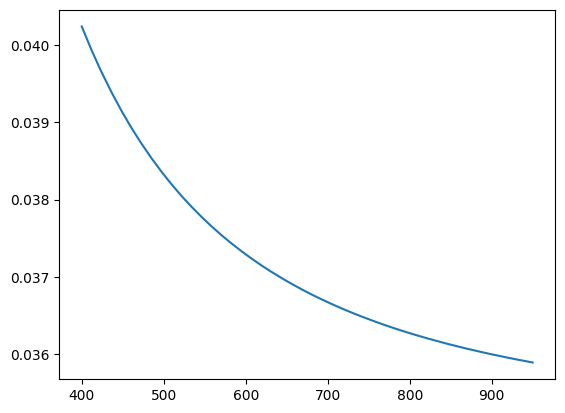

In [5]:
fig, ax = plt.subplots()

ax.plot(wls, refl)
#plt.text(750, 0.9, f"th={th}, tl={tl}")
plt.show()